In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import astropy.io.fits as fits
from scipy.optimize import curve_fit
import astropy.units as u
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.ticker as ticker

In [3]:
# get the planck color table 
my_rgb = np.loadtxt('planck_colors1_rgb.txt')
vals = np.ones((256, 4))
vals[:, 0] = my_rgb[:,0]/256.
vals[:, 1] = my_rgb[:,1]/256.
vals[:, 2] = my_rgb[:,2]/256.
newcmp = ListedColormap(vals)

In [4]:
fwhm_deg = 1
nside=128

In [5]:
# Using Planck PR3 857 GHz map smoothed to 1 degree, downgraded to NSIDE = 128
p857_map="../Templates/p857_dgsm.fits"
p857_dg=hp.fitsfunc.read_map(p857_map,field=[0])
# Maps used in fit are normalized by rms
rms_p857 =  np.std(p857_dg)
norm_p857 = p857_dg / rms_p857

In [6]:
# Using Planck PR3 545 GHz map smoothed to 1 degree, downgraded to NSIDE = 128
p545_map="../Templates/p545_dgsm.fits"
p545_dg=hp.fitsfunc.read_map(p545_map,field=[0])
# Maps used in fit are normalized by rms
rms_p545 =  np.std(p545_dg)
norm_p545 = p545_dg / rms_p545

In [7]:
# Using Haslam 408 MHz destriped map smoothed to 1 degree, downgraded to NSIDE = 128
h408_map="../Templates/h408_dgsm.fits"
h408_dg=hp.fitsfunc.read_map(h408_map,field=[0])
# Maps used in fit are normalized by rms
rms_h408 =  np.std(h408_dg)
norm_h408 = h408_dg / rms_h408

In [8]:
# Using DIRBE 240 micron ZSMA map smoothed to 1 degree, downgraded to NSIDE = 128
d240_map="../Templates/d240_dgsm.fits"
d240_dg=hp.fitsfunc.read_map(d240_map,field=[0])
# Maps used in fit are normalized by rms
rms_d240 =  np.std(d240_dg)
norm_d240 = d240_dg / rms_d240

In [9]:
# Using WMAP MEM free-free map (native resolution NSIDE = 128, smoothed to 1 degree)
ff_WMAP_map="wmap_K_mem_freefree_9yr_v5.fits.txt"
ff_WMAP=hp.fitsfunc.read_map(ff_WMAP_map,field=[0])
# Maps used in fit are normalized by rms
rms_WMAPff =  np.std(ff_WMAP)
norm_WMAPff = ff_WMAP / rms_WMAPff

In [10]:
# Using Planck Type 2 CO map smoothed to 1 degree, downgraded to NSIDE = 128
CO_map="../Templates/pCO_dgsm.fits"
CO_dg=hp.fitsfunc.read_map(CO_map,field=[0])
# Maps used in fit are normalized by rms
rms_CO =  np.std(CO_dg)
norm_CO = CO_dg / rms_CO

In [11]:
# Create a monopole map to use as the constant term
nside = 128 
alm = np.zeros(hp.Alm.getsize(0), dtype=complex)  
alm[hp.Alm.getidx(0, 0, 0)] = 1 

# Generate the map
map_l0_m0 = hp.alm2map(alm, nside)

# Normalize the map so that values = 1
norm_l0_m0 = (map_l0_m0 / map_l0_m0[0])

In [12]:
# Zodiacal light map creation described in Section 3.2
# Template is already at 1 degree, NSIDE = 128
zodi_map="../Templates/Zodiacal_template.fits"
zodi_dg=hp.fitsfunc.read_map(zodi_map,field=[0])
# Maps used in fit are normalized by rms
rms_zodi =  np.std(zodi_dg)
norm_zodi = zodi_dg / rms_zodi

In [13]:
# Kinematic quadrupole needs to be removed from WMAP bands (description in Section 3.2)
# Full-sky kinematic quadrupole evaluated at nside = 512, smoothed to 1 degree, downgraded to NSIDE=128:
kd_map="../Templates/kinquad_ns128_sm1degatns512_mk.fits"
t2_map_128=hp.fitsfunc.read_map(kd_map,field=[0])

In [14]:
# Pixels removed by 1% mask are not included during fit (see Section 3.6)
mask="../Masks/1percent_mask.fits"
mask=hp.fitsfunc.read_map(mask,field=[0])

### Import Bands

In [15]:
p217_map="HFI_SkyMap_217-field-IQU_2048_R3.00_full.fits"
p217=hp.fitsfunc.read_map(p217_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'BeamWf_HFI_R3.01/Bl_T_R3.01_fullsky_217x217.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[1].data  
p217_bl = tbdata['TEMPERATURE']
p217_ell = np.arange(0,len(p217_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p217_ell*(p217_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p217_bl
smth217_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 217 GHz beam window function
sm_r11_217 = hp.smoothing(p217, beam_window=smth217_kernel)

# Downgrade maps to NSIDE = 128
p217_dg = hp.ud_grade(sm_r11_217, nside)
# convert to mK (Thermodynamic)
p217_dg = p217_dg * 1000

In [16]:
p143_map="HFI_SkyMap_143-field-IQU_2048_R3.00_full.fits"
p143=hp.fitsfunc.read_map(p143_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'BeamWf_HFI_R3.01/Bl_T_R3.01_fullsky_143x143.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[1].data  
p143_bl = tbdata['TEMPERATURE']
p143_ell = np.arange(0,len(p143_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p143_ell*(p143_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p143_bl
smth143_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 143 GHz beam window function
sm_r11_143 = hp.smoothing(p143, beam_window=smth143_kernel)

# Downgrade maps to NSIDE = 128
p143_dg = hp.ud_grade(sm_r11_143, nside)

# Convert to mK 
p143_dg = p143_dg * 1000

In [17]:
p100_map="HFI_SkyMap_100-field-IQU_2048_R3.00_full.fits"
p100=hp.fitsfunc.read_map(p100_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'BeamWf_HFI_R3.01/Bl_T_R3.01_fullsky_100x100.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[1].data  
p100_bl = tbdata['TEMPERATURE']
p100_ell = np.arange(0,len(p100_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p100_ell*(p100_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p100_bl
smth100_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 100 GHz beam window function
sm_r11_100 = hp.smoothing(p100, beam_window=smth100_kernel)

# Downgrade maps to NSIDE = 128
p100_dg = hp.ud_grade(sm_r11_100, nside)

# convert to mK (Thermodynamic)
p100_dg = p100_dg * 1000

In [18]:
p70_map="LFI_SkyMap_070-BPassCorrected-field-IQU_1024_R3.00_full.fits"
p70=hp.fitsfunc.read_map(p70_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'LFI_RIMO_R3.31.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[30].data  
p70_bl = tbdata['BL      ']
p70_ell = np.arange(0,len(p70_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p70_ell*(p70_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p70_bl
smth70_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 70 GHz beam window function
sm_r11_70 = hp.smoothing(p70, beam_window=smth70_kernel)

# Downgrade maps to NSIDE = 128
p70_dg = hp.ud_grade(sm_r11_70, nside)

# convert to mK (Thermodynamic)
p70_dg = p70_dg * 1000

In [19]:
p44_map="LFI_SkyMap_044-BPassCorrected-field-IQU_1024_R3.00_full.fits"
p44=hp.fitsfunc.read_map(p44_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'LFI_RIMO_R3.31.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[29].data  
p44_bl = tbdata['BL      ']
p44_ell = np.arange(0,len(p44_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p44_ell*(p44_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p44_bl
smth44_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 44 GHz beam window function
sm_r11_44 = hp.smoothing(p44, beam_window=smth44_kernel)

# Downgrade maps to NSIDE = 128
p44_dg = hp.ud_grade(sm_r11_44, nside)

# convert to mK (Thermodynamic)
p44_dg = p44_dg * 1000

In [20]:
p30_map="LFI_SkyMap_030-BPassCorrected-field-IQU_1024_R3.00_full.fits"
p30=hp.fitsfunc.read_map(p30_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'LFI_RIMO_R3.31.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[28].data  
p30_bl = tbdata['BL      ']
p30_ell = np.arange(0,len(p30_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p30_ell*(p30_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p30_bl
smth30_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 44 GHz beam window function
sm_r11_30 = hp.smoothing(p30, beam_window=smth30_kernel)

# Downgrade maps to NSIDE = 128
p30_dg = hp.ud_grade(sm_r11_30, nside)

# convert to mK (Thermodynamic)
p30_dg = p30_dg * 1000

In [21]:
# Map is already smoothed to 1 degree
wmapk_map="wmap_band_smth_imap_r9_9yr_K_v5.fits"
wmapk=hp.fitsfunc.read_map(wmapk_map,field=[0])

# Downgrade maps to NSIDE = 128
wmapk_dg = hp.ud_grade(wmapk, nside)

In [22]:
# Map is already smoothed to 1 degree
wmapka_map="wmap_band_smth_imap_r9_9yr_Ka_v5.fits"
wmapka=hp.fitsfunc.read_map(wmapka_map,field=[0])

# Downgrade maps to NSIDE = 128
wmapka_dg = hp.ud_grade(wmapka, nside)

In [23]:
# Map is already smoothed to 1 degree
wmapq_map="wmap_band_smth_imap_r9_9yr_Q_v5.fits"
wmapq=hp.fitsfunc.read_map(wmapq_map,field=[0])

# Downgrade maps to NSIDE = 128
wmapq_dg = hp.ud_grade(wmapq, nside)

In [24]:
# Map is already smoothed to 1 degree
wmapv_map="wmap_band_smth_imap_r9_9yr_V_v5.fits"
wmapv=hp.fitsfunc.read_map(wmapv_map,field=[0])

# Downgrade maps to NSIDE = 128
wmapv_dg = hp.ud_grade(wmapv, nside)

In [25]:
# Map is already smoothed to 1 degree
wmapw_map="wmap_band_smth_imap_r9_9yr_W_v5.fits"
wmapw=hp.fitsfunc.read_map(wmapw_map,field=[0])

# Downgrade maps to NSIDE = 128
wmapw_dg = hp.ud_grade(wmapw, nside)

In [26]:
# Remove Kinematic quadrupole from WMAP maps
wmapk_kq = wmapk_dg-t2_map_128
wmapka_kq = wmapka_dg-t2_map_128
wmapq_kq = wmapq_dg-t2_map_128
wmapv_kq = wmapv_dg-t2_map_128
wmapw_kq = wmapw_dg-t2_map_128

In [27]:
# Apply zodiacal light correction to 100 GHz and 143 GHz (see Section 3.2)
p100_nz = p100_dg +0.001*norm_zodi
p143_nz = p143_dg + 0.001*norm_zodi

### Curvefit

In [28]:
# Function for templates: linear combination
def func_t(x,amp1,amp2, amp3, amp4, amp5, amp6, const):
    pmap = amp1*x[0,:] + amp2*x[1,:] + amp3*x[2,:] + amp4*x[3,:] + amp5*x[4,:] + amp6*x[5,:] + const*x[6,:]
    return pmap

In [29]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(p217_dg)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = p217_dg[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_217_6, pcov_217_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [30]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(p143_nz)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = p143_nz[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf , -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_143_6, pcov_143_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [31]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(p100_nz)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel],const[isel]])
ydata = p100_nz[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])	

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf , -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_100_6, pcov_100_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds]) 

In [32]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(p70_dg)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = p70_dg[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_70_6, pcov_70_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [33]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(p44_dg)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = p44_dg[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_44_6, pcov_44_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [34]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(p30_dg)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = p30_dg[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_30_6, pcov_30_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [35]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(wmapk_kq)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = (wmapk_kq)[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_23_6, pcov_23_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [36]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(wmapka_kq)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const =norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = (wmapka_kq)[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_33_6, pcov_33_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [37]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(wmapq_kq)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = (wmapq_kq)[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_41_6, pcov_41_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [38]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(wmapv_kq)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = (wmapv_kq)[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_61_6, pcov_61_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [39]:
# Select portion of map to fit: |b| <= 10 degrees and exclude pixels from 1% mask
glon, glat = hp.pix2ang(128, np.arange(len(wmapw_kq)), lonlat=True)
isel, = np.where((abs(glat) <= 10) & (mask != 0))

# 6 templates + constant term
x1 = norm_p857
x2 = norm_h408
x3 = norm_d240
x4 = norm_WMAPff
x5 = norm_CO
x6 = norm_p545
const = norm_l0_m0

# Apply fit for |b| <= 10 degrees and excluding pixels from mask
xdata = np.array([x1[isel],x2[isel],x3[isel],x4[isel],x5[isel],x6[isel], const[isel]])
ydata = (wmapw_kq)[isel]
# Flat weights
ysig  = ydata*0.0 + 1.
# Input guesses for fit parameters 
p0    = np.array([0.1, 0.05, 0.01, 0.05, 0.01, 0.1, 0])  # input guesses for fit parameters 

# Allow template coefficients to be positive or negative
lo_bounds = [ -np.inf, -np.inf , -np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
hi_bounds = [ np.inf, np.inf ,np.inf, np.inf, np.inf, np.inf, np.inf]

# Solve for the coefficients using curve_fit
popt_94_6, pcov_94_6 = curve_fit(func_t, xdata, ydata, p0, sigma=ysig, absolute_sigma=False, bounds=[lo_bounds, hi_bounds])

In [40]:
# Errors from covariance matrices
perr_23_6 = np.sqrt(np.diag(pcov_23_6))
perr_30_6 = np.sqrt(np.diag(pcov_30_6))
perr_33_6 = np.sqrt(np.diag(pcov_33_6))
perr_41_6 =np.sqrt(np.diag(pcov_41_6))
perr_44_6 = np.sqrt(np.diag(pcov_44_6))
perr_61_6 = np.sqrt(np.diag(pcov_61_6))
perr_70_6 = np.sqrt(np.diag(pcov_70_6))
perr_94_6 = np.sqrt(np.diag(pcov_94_6))
perr_100_6 = np.sqrt(np.diag(pcov_100_6))
perr_143_6 = np.sqrt(np.diag(pcov_143_6))
perr_217_6 = np.sqrt(np.diag(pcov_217_6))

In [41]:
p857_p545_co_6 = [popt_23_6[0]/popt_23_6[5], popt_30_6[0]/popt_30_6[5], popt_33_6[0]/popt_33_6[5], popt_41_6[0]/popt_41_6[5], popt_44_6[0]/popt_44_6[5], popt_61_6[0]/popt_61_6[5], popt_70_6[0]/popt_70_6[5],  popt_94_6[0]/popt_94_6[5], popt_100_6[0]/popt_100_6[5], popt_143_6[0]/popt_143_6[5], popt_217_6[0]/popt_217_6[5]]
p857_co = [popt_23_6[0], popt_30_6[0], popt_33_6[0], popt_41_6[0], popt_44_6[0], popt_61_6[0], popt_70_6[0],  popt_94_6[0], popt_100_6[0], popt_143_6[0], popt_217_6[0]]
h408_co = [popt_23_6[1], popt_30_6[1], popt_33_6[1], popt_41_6[1], popt_44_6[1], popt_61_6[1], popt_70_6[1],  popt_94_6[1], popt_100_6[1], popt_143_6[1], popt_217_6[1]]
d240_co = [popt_23_6[2], popt_30_6[2], popt_33_6[2], popt_41_6[2], popt_44_6[2], popt_61_6[2], popt_70_6[2],  popt_94_6[2], popt_100_6[2], popt_143_6[2], popt_217_6[2]]
wmapff_co = [popt_23_6[3], popt_30_6[3], popt_33_6[3], popt_41_6[3], popt_44_6[3], popt_61_6[3], popt_70_6[3],  popt_94_6[3], popt_100_6[3], popt_143_6[3], popt_217_6[3]]
pCO_co = [popt_23_6[4], popt_30_6[4], popt_33_6[4], popt_41_6[4], popt_44_6[4], popt_61_6[4], popt_70_6[4],  popt_94_6[4], popt_100_6[4], popt_143_6[4], popt_217_6[4]]
p545_co = [popt_23_6[5], popt_30_6[5], popt_33_6[5], popt_41_6[5], popt_44_6[5], popt_61_6[5], popt_70_6[5],  popt_94_6[5], popt_100_6[5], popt_143_6[5], popt_217_6[5]]
const_co = [popt_23_6[6], popt_30_6[6], popt_33_6[6], popt_41_6[6], popt_44_6[6], popt_61_6[6], popt_70_6[6],  popt_94_6[6], popt_100_6[6], popt_143_6[6], popt_217_6[6]]

p857_err = [perr_23_6[0], perr_30_6[0], perr_33_6[0], perr_41_6[0], perr_44_6[0], perr_61_6[0], perr_70_6[0],  perr_94_6[0], perr_100_6[0], perr_143_6[0], perr_217_6[0]]
h408_err = [perr_23_6[1], perr_30_6[1], perr_33_6[1], perr_41_6[1], perr_44_6[1], perr_61_6[1], perr_70_6[1],  perr_94_6[1], perr_100_6[1], perr_143_6[1], perr_217_6[1]]
d240_err = [perr_23_6[2], perr_30_6[2], perr_33_6[2], perr_41_6[2], perr_44_6[2], perr_61_6[2], perr_70_6[2],  perr_94_6[2], perr_100_6[2], perr_143_6[2], perr_217_6[2]]
wmapff_err = [perr_23_6[3], perr_30_6[3], perr_33_6[3], perr_41_6[3], perr_44_6[3], perr_61_6[3], perr_70_6[3],  perr_94_6[3], perr_100_6[3], perr_143_6[3], perr_217_6[3]]
pCO_err = [perr_23_6[4], perr_30_6[4], perr_33_6[4], perr_41_6[4], perr_44_6[4], perr_61_6[4], perr_70_6[4],  perr_94_6[4], perr_100_6[4], perr_143_6[4], perr_217_6[4]]
p545_err = [perr_23_6[5], perr_30_6[5], perr_33_6[5], perr_41_6[5], perr_44_6[5], perr_61_6[5], perr_70_6[5],  perr_94_6[5], perr_100_6[5], perr_143_6[5], perr_217_6[5]]
const_err = [perr_23_6[6], perr_30_6[6], perr_33_6[6], perr_41_6[6], perr_44_6[6], perr_61_6[6], perr_70_6[6],  perr_94_6[6], perr_100_6[6], perr_143_6[6], perr_217_6[6]]

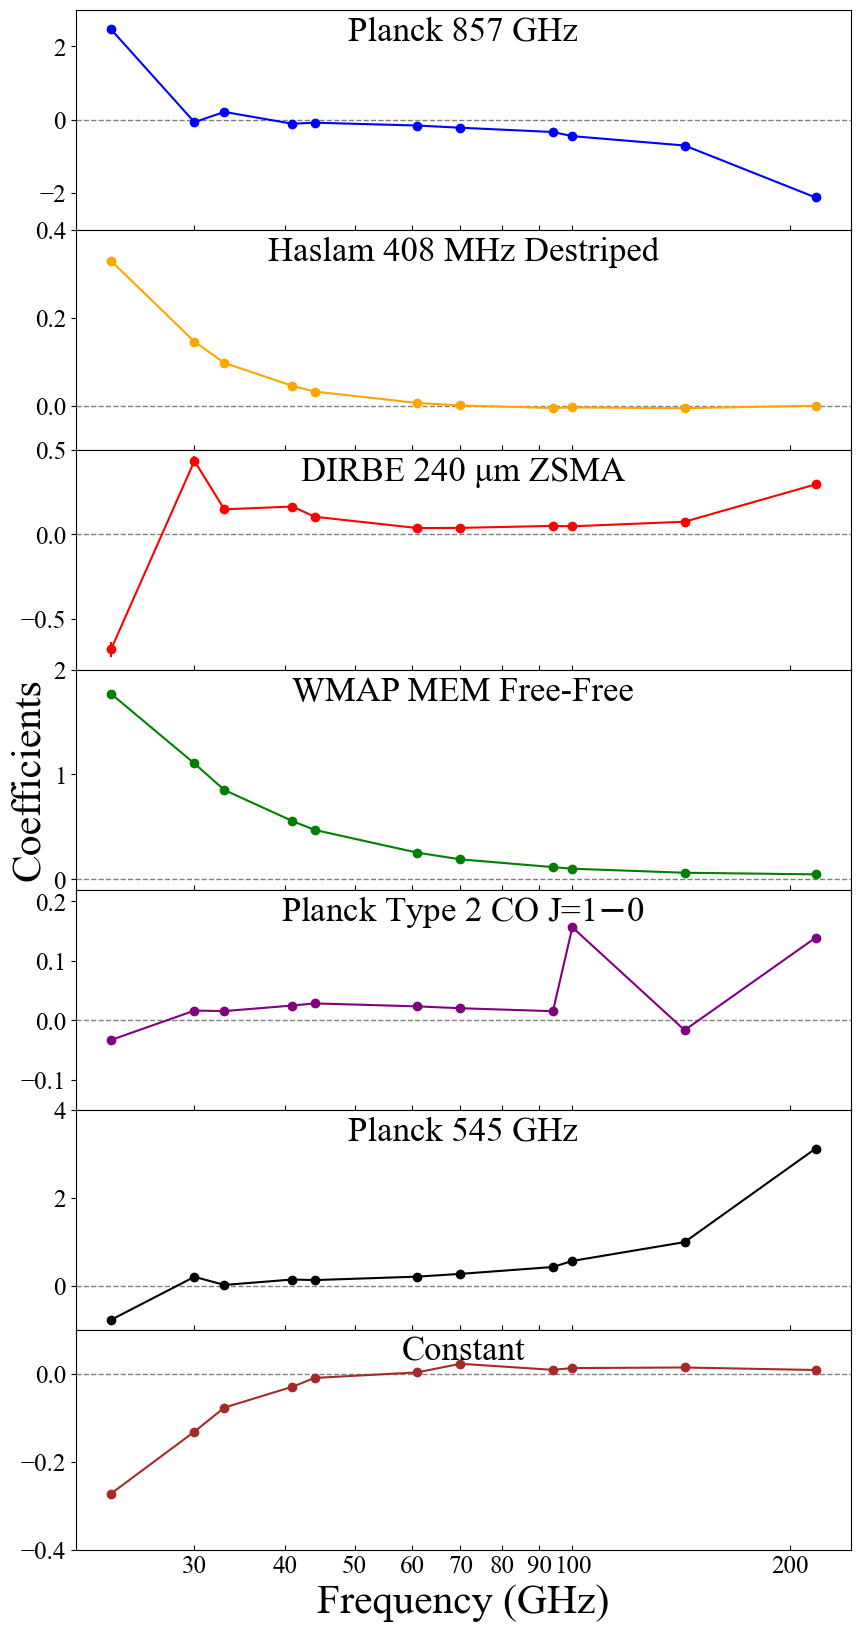

In [42]:
plt.rcParams.update({'font.size': 18})
plt.rcParams['font.family'] = 'Times New Roman'

figsize = (10, 20)
fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
maps = ['P3 857', 'Haslam 408', 'DIRBE 240', 'WMAP FF', 'P Type-2 CO', 'P3 545', 'Constant']
freq = (23, 30, 33, 41, 44, 61, 70, 94, 100, 143, 217)
ymin = (-3,-0.1,-0.8,-0.1,-0.15,-1,-0.4)
ymax = (3,0.4,0.5,2,0.22,4,0.1)

# Data
datasets = [
    (p857_co, p857_err, 'Planck 857 GHz', 'blue'),
    (h408_co, h408_err, 'Haslam 408 MHz Destriped', 'orange'),
    (d240_co, d240_err, 'DIRBE 240 μm ZSMA', 'red'),
    (wmapff_co, wmapff_err, 'WMAP MEM Free-Free', 'green'),
    (pCO_co, pCO_err, 'Planck Type 2 CO J=1$-$0', 'purple'),
    (p545_co, p545_err, 'Planck 545 GHz', 'black'),
    (const_co, const_err, 'Constant', 'brown')
]

# Loop through each template and plot them in a separate subplot
for i, (data, error, label, color) in enumerate(datasets):
    axes[i].errorbar(freq, data, yerr=error, marker='o', color=color)
    axes[i].text(0.5, 0.86, label, transform=axes[i].transAxes, fontsize=25, horizontalalignment='center')
    axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=1)
    axes[i].set_ylim(ymin[i],ymax[i])
    if i == 3:
        axes[i].set_ylabel('Coefficients',fontsize=30)
        
axes[-1].set_xlabel('Frequency (GHz)',fontsize=30)
# Set logarithmic scale for x-axis
axes[-1].set_xscale('log')
  

# Format the x-axis to show every 10 GHz
xticks = [30, 40, 50, 60, 70, 80, 90, 100, 200]
for ax in axes:
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(ticker.ScalarFormatter())
    ax.tick_params(axis='x', direction='in', top=False, bottom=True)

plt.subplots_adjust(hspace=0.0)   